In [1]:
import matplotlib.pyplot as plt
import numpy as np
import qutip as qt
from IPython.display import display, Math, Latex

from IPython.display import display, Math, Latex
import ipywidgets as widgets
from matplotlib.widgets import Slider, Button

from scipy.fft import fft, ifft
import scipy.special as sp
import scipy.optimize 

import matplotlib.ticker as tkr
import matplotlib as mpl
import matplotlib.mlab as mlab
import matplotlib.colors

In [2]:
Delta = 0 #no detuning
kappa = 300e6*2*np.pi
drive = 0
n_levels = 100
theta = np.pi/16
phi = 0
lam = 0.45 * kappa #-0.452267 #20 dB #-0.426141

In [3]:
def DPA(kappa, lam, drive, n_levels, theta, phi):
        
    a = qt.destroy(n_levels) 
     
    H_DPA = Delta * a.dag() * a + lam*np.exp(-1j*theta)/2 * a.dag()*a.dag() + lam*np.exp(1j*theta)/2 * a * a

    epsilon = drive*kappa*np.exp(-1j*phi)
    H_probe = epsilon * a.dag() + np.conj(epsilon) * a
    
    c_op_list = [np.sqrt(kappa) * a]
    final_state = qt.steadystate(H_DPA+H_probe, c_op_list)

    return final_state

In [4]:
run_DPA = DPA(kappa, lam, drive, n_levels, -np.pi/2, phi)

In [5]:
xvec=np.linspace(-4,4, 500)
yvec=np.linspace(-4,4, 500)

W_DPA=qt.wigner(run_DPA, xvec, yvec, g=2)
W_DPA=np.around(W_DPA, decimals=2)

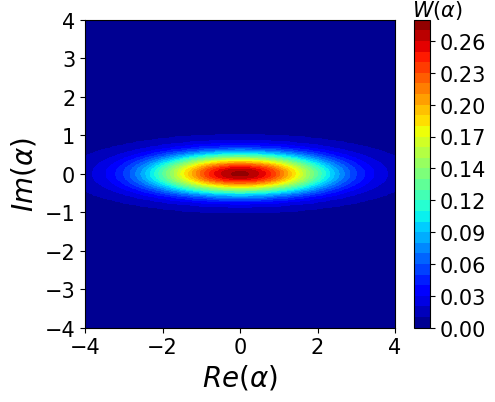

In [6]:
plt.figure(figsize=(5, 4))
p1=plt.contourf(xvec,yvec, W_DPA, cmap=plt.cm.jet, levels=np.linspace(W_DPA.min(),W_DPA.max(), 30))
#plt.colorbar()
cb = plt.colorbar(p1, format=tkr.FormatStrFormatter('%.2f'))
cb.set_label(r'$W(\alpha)$', labelpad=-35, y=1.07, rotation=0, size=15)
cb.ax.tick_params(labelsize=15)
#plt.title(r'$\Lambda=10^{-3}\kappa$', fontsize=20)
plt.xlabel(r'$Re(\alpha)$', fontsize=20)
plt.ylabel(r'$Im(\alpha)$', fontsize=20)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.savefig("DPA Wigner.jpeg", bbox_inches='tight')

In [7]:
# JPA parameters
F_JPA = np.pi/4
EC_J = 9e6 * 2*np.pi #1e6 * 2*np.pi #85e4 * 2*np.pi
EJ = 2000e9 * 2*np.pi #2000e9 * 2*np.pi #2357e9 * 2*np.pi
phi_zpf_JPA = (2*EC_J/EJ)**0.25
JPA_ratio = phi_zpf_JPA**2/6 # |LAM/lam| ratio in abs value
w0 = np.sqrt(8*EJ*EC_J)

Kerr = -EC_J * np.cos(F_JPA) / 2
print(Kerr/kappa)
print(JPA_ratio)
print(w0/2/np.pi)
print(JPA_ratio*lam)

-0.010606601717798213
0.0005
12000000000.0
424115.0082346221


In [8]:
def JPA(kappa,lam, Kerr, ratio, drive, n_levels, theta, phi):
        
    a = qt.destroy(n_levels) 
     
    H_DPA = Delta * a.dag() * a + lam*np.exp(-1j*theta)/2 * a.dag()*a.dag() + lam*np.exp(1j*theta)/2 * a * a

    epsilon = drive*kappa*np.exp(-1j*phi)
    LAM = -ratio * lam

    H_alpha =  Kerr * a.dag()*a.dag()*a*a + LAM * (a.dag()*a.dag()*a.dag()*a + a.dag() * a * a * a) 
    H_probe = epsilon * a.dag() + np.conj(epsilon) * a
    
    c_op_list = [np.sqrt(kappa) * a]
    final_state = qt.steadystate(H_DPA+H_alpha+H_probe, c_op_list)

    return final_state

In [9]:
run_JPA = JPA(kappa, lam, Kerr, JPA_ratio, drive, n_levels, theta, phi)

In [10]:
xvec=np.linspace(-4,4, 500)
yvec=np.linspace(-4,4, 500)

W_JPA=qt.wigner(run_JPA, xvec, yvec, g=2)
W_JPA=np.around(W_JPA, decimals=2)

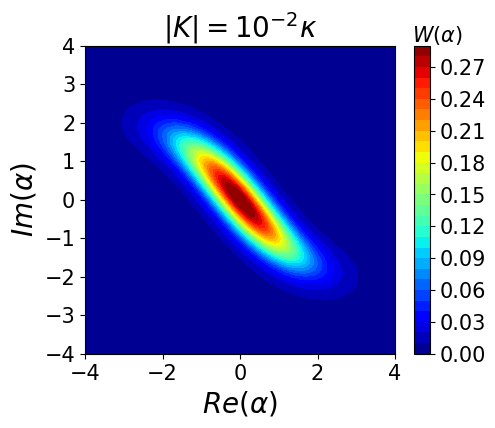

In [11]:
plt.figure(figsize=(5, 4))
p2=plt.contourf(xvec,yvec, W_JPA, cmap=plt.cm.jet, levels=np.linspace(W_JPA.min(),W_JPA.max(), 30))
#plt.colorbar()
cb = plt.colorbar(p2, format=tkr.FormatStrFormatter('%.2f'))
cb.set_label(r'$W(\alpha)$', labelpad=-35, y=1.07, rotation=0, size=15)
cb.ax.tick_params(labelsize=15)
plt.title(r'$|K|=10^{-2}\kappa$', fontsize=20)
plt.xlabel(r'$Re(\alpha)$', fontsize=20)
plt.ylabel(r'$Im(\alpha)$', fontsize=20)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.savefig("JPA Wigner.jpeg", bbox_inches='tight')

In [12]:
run_JPA2 = JPA(kappa, lam, 0, JPA_ratio, drive, n_levels, theta, phi)

In [13]:
xvec=np.linspace(-4,4, 500)
yvec=np.linspace(-4,4, 500)

W_JPA2=qt.wigner(run_JPA2, xvec, yvec, g=2)
W_JPA2=np.around(W_JPA2, decimals=2)

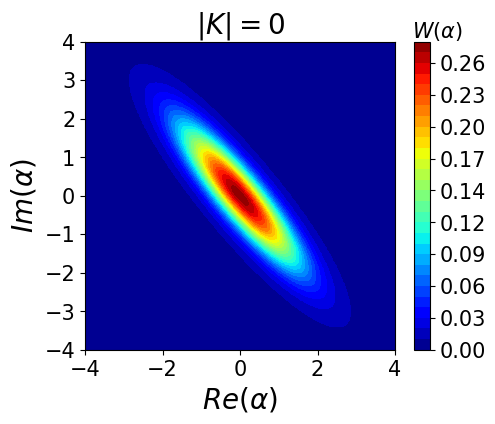

In [14]:
plt.figure(figsize=(5, 4))
p2=plt.contourf(xvec,yvec, W_JPA2, cmap=plt.cm.jet, levels=np.linspace(W_JPA2.min(),W_JPA2.max(), 30))
#plt.colorbar()
cb = plt.colorbar(p2, format=tkr.FormatStrFormatter('%.2f'))
cb.set_label(r'$W(\alpha)$', labelpad=-35, y=1.07, rotation=0, size=15)
cb.ax.tick_params(labelsize=15)
plt.title(r'$|K|=0$', fontsize=20)
plt.xlabel(r'$Re(\alpha)$', fontsize=20)
plt.ylabel(r'$Im(\alpha)$', fontsize=20)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.savefig("Kerr-free JPA Wigner.jpeg", bbox_inches='tight')

In [15]:
run_JPA3 = JPA(kappa, lam, Kerr, 0, drive, n_levels, theta, phi)

In [16]:
xvec=np.linspace(-4,4, 500)
yvec=np.linspace(-4,4, 500)

W_JPA3=qt.wigner(run_JPA3, xvec, yvec, g=2)
W_JPA3=np.around(W_JPA3, decimals=2)

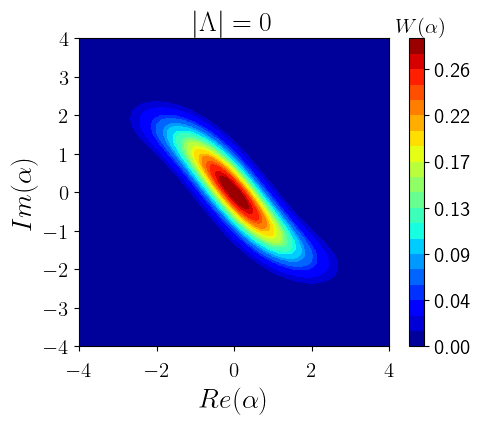

In [27]:
plt.figure(figsize=(5, 4))
p3=plt.contourf(xvec,yvec, W_JPA3, cmap=plt.cm.jet, levels=np.linspace(W_JPA3.min(),W_JPA3.max(), 21))
#plt.colorbar()
cb = plt.colorbar(p3, format=tkr.FormatStrFormatter('%.2f'))
cb.set_label(r'$W(\alpha)$', labelpad=-35, y=1.07, rotation=0, size=15)
cb.ax.tick_params(labelsize=15)
plt.title(r'$|\Lambda|=0$', fontsize=20)
plt.xlabel(r'$Re(\alpha)$', fontsize=20)
plt.ylabel(r'$Im(\alpha)$', fontsize=20)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.savefig("LAM-free JPA Wigner.jpeg", bbox_inches='tight')

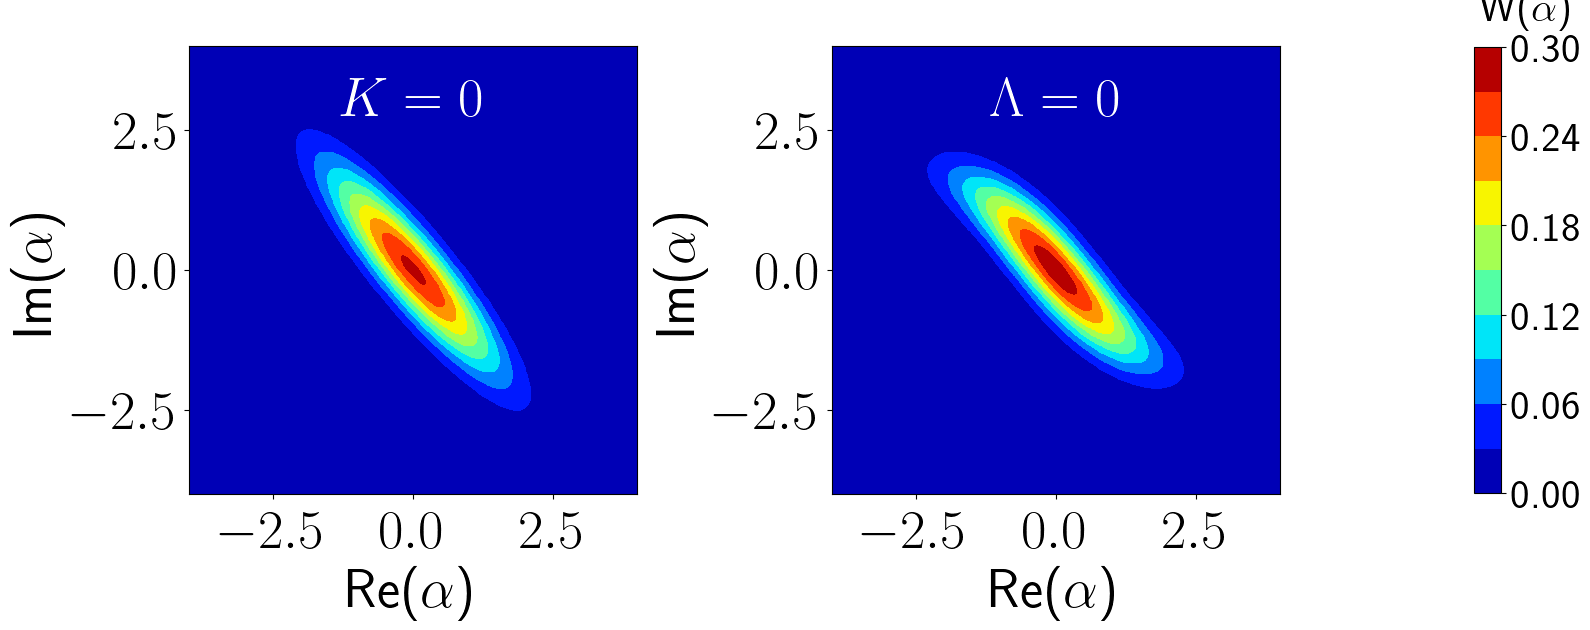

In [142]:
gridspec = {'width_ratios': [1, 1, 0.06]}
fig, ax = plt.subplots(1, 3, figsize=(16,8), gridspec_kw=gridspec)
plt.rcParams['text.usetex'] = True
lev = np.linspace(0.0, 0.3,11)

ax[0].contourf(xvec,yvec, W_JPA2, cmap=plt.cm.jet, levels=lev)
ax[0].set_xlabel(r'Re($\alpha$)', fontsize=40)
ax[0].set_ylabel(r'Im($\alpha$)', fontsize=40)
#ax[0].set_title(r'$K=0$', fontsize=40)
ax[0].tick_params(axis='both', which='major', labelsize=40)
ax[0].set_yticks([-2.5,0,2.5])
ax[0].set_xticks([-2.5,0,2.5])
ax[0].text(0, 3, r'$K=0$', fontsize=40, color='white', ha='center', va='center')


plt.sca(ax[1])
plt.contourf(xvec,yvec, W_JPA3, cmap=plt.cm.jet, levels=lev)
ax[1].set_xlabel(r'Re($\alpha$)', fontsize=40)
ax[1].set_ylabel(r'Im($\alpha$)', fontsize=40)
#ax[1].set_title(r'$\Lambda=0$', fontsize=40)
ax[1].set_yticks([-2.5,0,2.5])
ax[1].set_xticks([-2.5,0,2.5])
ax[1].tick_params(axis='both', which='major', labelsize=40)
ax[1].text(0, 3, r'$\Lambda=0$', fontsize=40, color='white', ha='center', va='center')



for axes in ax[:2]:
    axes.set_aspect("equal")

cax = ax[2]
cb = plt.colorbar(cax=cax, format=tkr.FormatStrFormatter('%.2f'))
cb.set_label(r'W($\alpha$)', labelpad=-39, y=1.13, rotation=0, size=30)
cb.ax.tick_params(labelsize=30)
ax[2].set_aspect(16.6)

#fig.text(0.477, -0.07, r'Re($\alpha$)', ha='center', fontsize=50)
#fig.text(0.04, 0.5, r'Im($\alpha$)', va='center', rotation='vertical', fontsize=50)
#plt.subplots_adjust(wspace=0, hspace=0)
plt.tight_layout()
plt.savefig("K-free and LAM-free Wigners.jpeg", bbox_inches='tight')
plt.show()

#cb = plt.colorbar(p1, format=tkr.FormatStrFormatter('%.2f'))
#cb.set_label('W(\u03B1)', labelpad=-35, y=1.07, rotation=0, size=15)
#cb.ax.tick_params(labelsize=15)

#plt.xticks(fontsize=15)
#plt.yticks(fontsize=15)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('Deviation_vs_LAM.csv')
x_data = df['x_val']
y1_data = df['y_val_plot1']
y2_data = df['y_val_plot2']

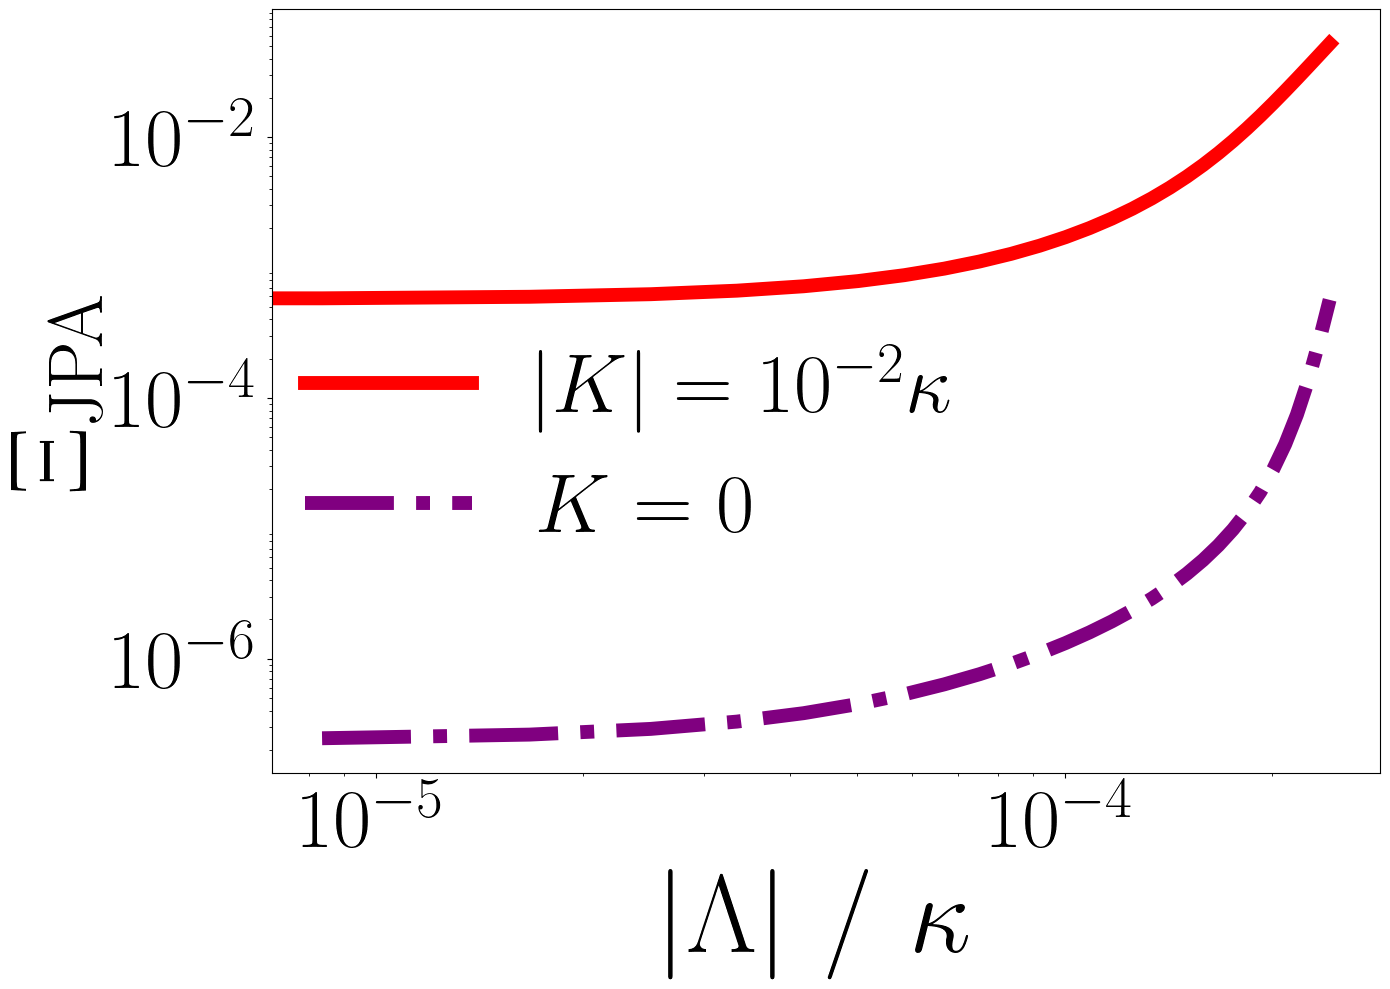

In [4]:
plt.figure(figsize=(14,10))
plt.rcParams['text.usetex'] = True
plt.rcParams['xtick.major.pad'] = 8
#plt.plot(-lam_range, Dev_DPA, '--', c='blue', linewidth=5, label = 'DPA')
plt.plot(x_data, y1_data, '-', c='red', linewidth=10, label = r'$|K|=10^{-2}\kappa$') #, $|\lambda|=2000 \Lambda$')
plt.plot(x_data, y2_data,'-.', c='purple', linewidth=10, label = r'$K=0$')#, $|\lambda|=2000 \Lambda$')



plt.legend(loc=(0,0.25),fontsize=60,framealpha=0.0)
plt.xlabel(r'$|\Lambda|$ / $\kappa$',fontsize=80)
plt.ylabel(r'$\Xi_{\rm JPA}$', fontsize=80)
plt.xscale('log')
plt.yscale('log')
plt.xticks(fontsize=60)
plt.yticks([1e-6,1e-4,1e-2],fontsize=60)
plt.tight_layout()
plt.savefig("Deviation from DPA.jpeg")

In [5]:
dfl = pd.read_csv('Deviation_vs_drive.csv')
xl_data = dfl['x_val']
y1l_data = dfl['y_val_plot1']
y2l_data = dfl['y_val_plot2']
y3l_data = dfl['y_val_plot3']

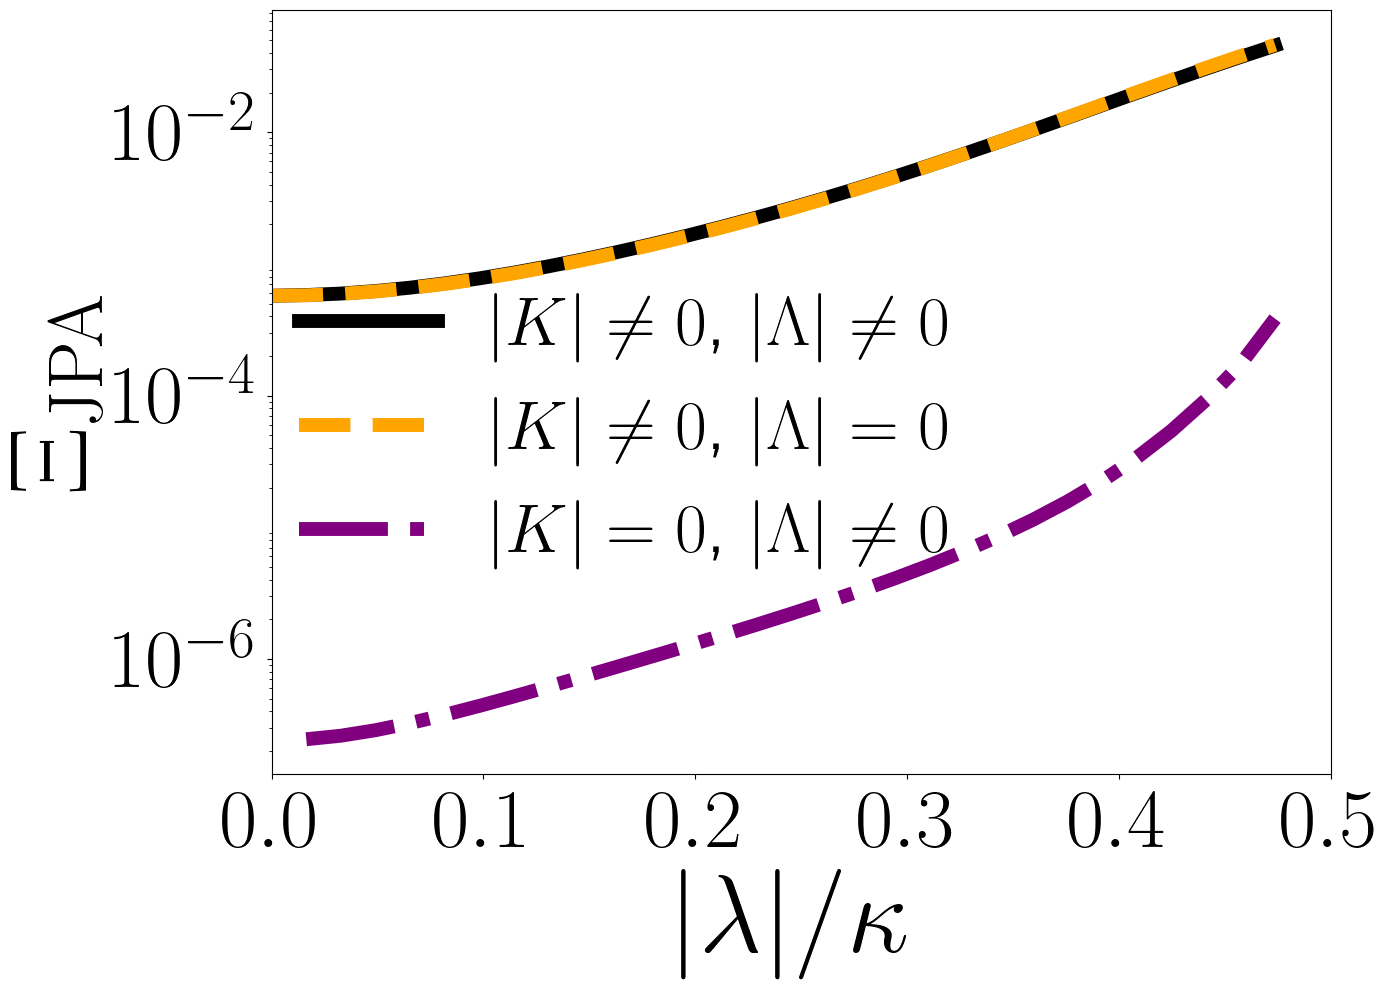

In [14]:
plt.figure(figsize=(14,10))
plt.rcParams['text.usetex'] = True
plt.plot(xl_data, y1l_data, c='black', linewidth=10, label = r'$|K|\neq 0$, $|\Lambda|\neq 0$')#, $\Lambda=5\times 10^{-4}|\lambda|$')
plt.plot(xl_data, y2l_data, '--', c='orange', linewidth=10, label = r'$|K|\neq 0$, $|\Lambda|=0$')#, $\Lambda=0$')
plt.plot(xl_data, y3l_data, '-.', c='purple', linewidth=10, label = r'$|K|=0$, $|\Lambda|\neq 0$')#, $\Lambda=5\times 10^{-4}|\lambda|$')





plt.legend(loc=(0,0.23), fontsize=50,framealpha=0.0)
plt.xlabel(r'$|\lambda|/\kappa$',fontsize=80)
plt.ylabel(r'$\Xi_{\rm JPA}$', fontsize=80)
#plt.xscale('log')
plt.yscale('log')
plt.xlim(0,0.5)
plt.xticks(fontsize=60)
plt.yticks([1e-6,1e-4,1e-2],fontsize=60)
plt.tight_layout()
plt.savefig("Deviation from DPA2.jpeg")

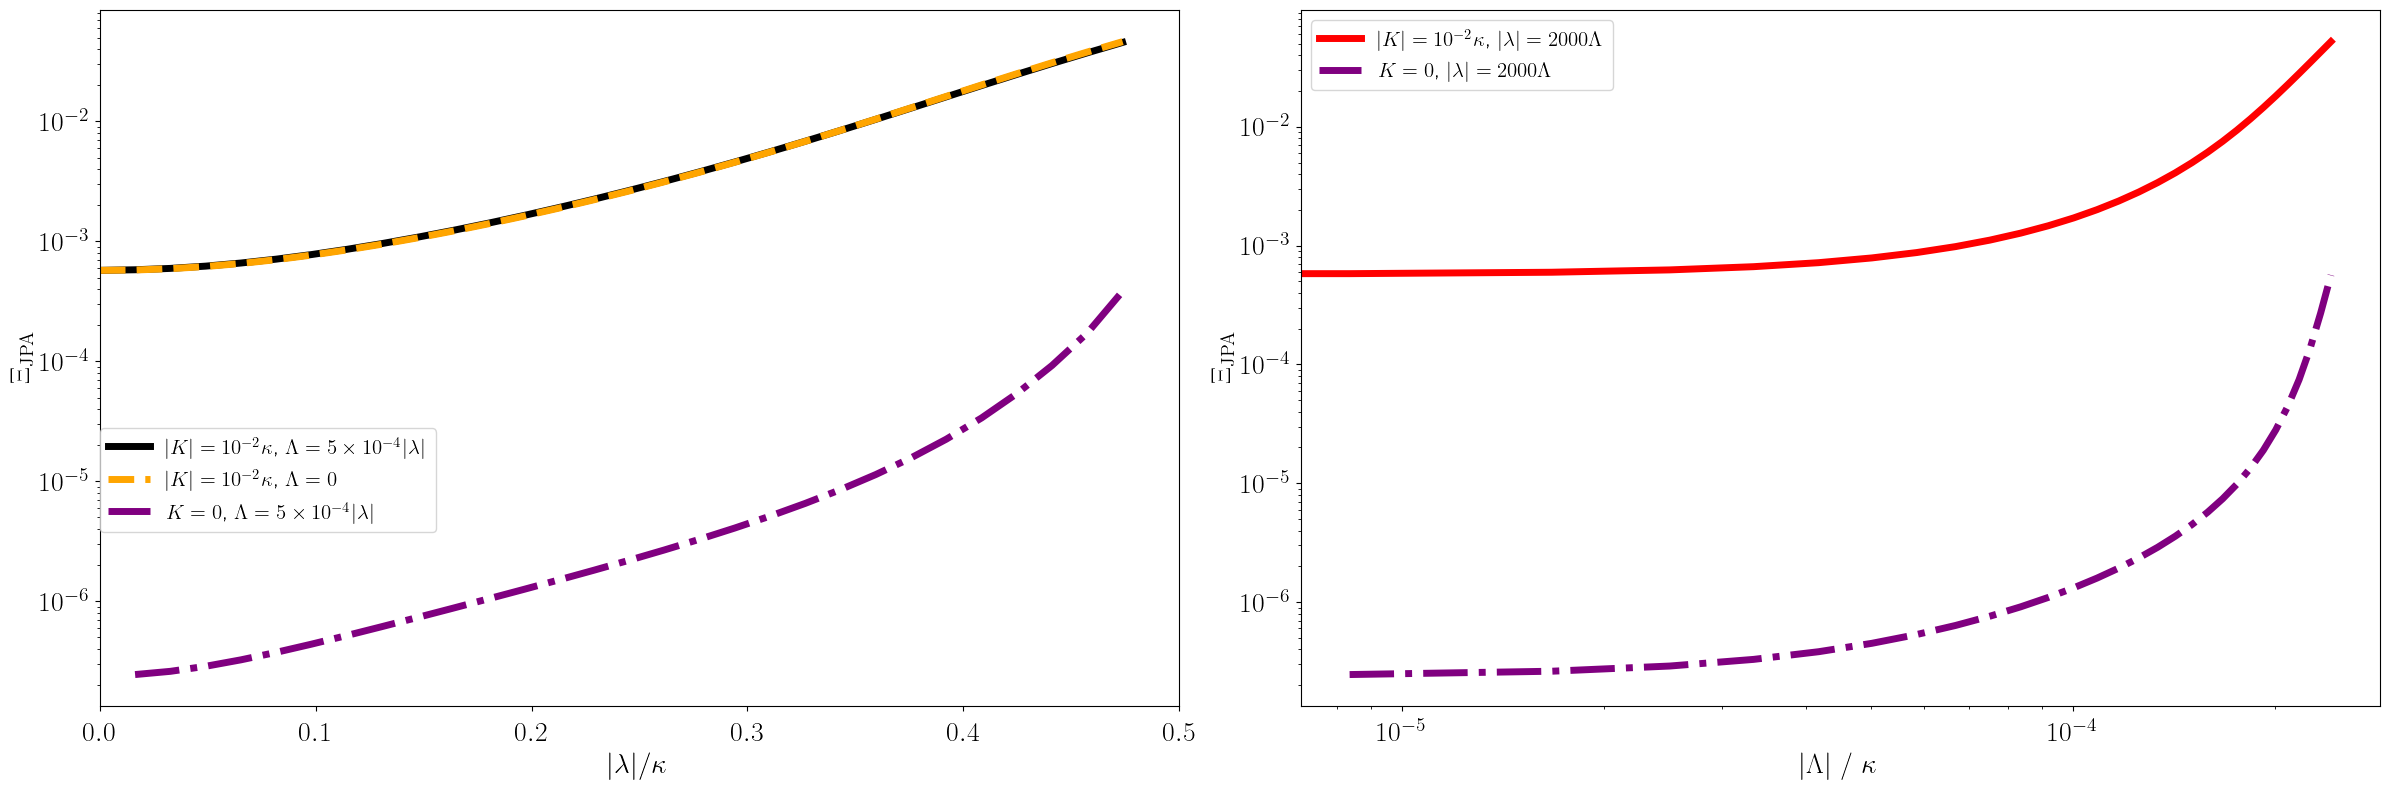

In [96]:
import matplotlib.pyplot as plt
import numpy as np


fig, ax = plt.subplots(1, 2, figsize=(24,8))
plt.rcParams['text.usetex'] = True


ax[0].plot(xl_data, y1l_data, c='black', linewidth=5, label = r'$|K|=10^{-2}\kappa$, $\Lambda=5\times 10^{-4}|\lambda|$')
ax[0].plot(xl_data, y2l_data, '--', c='orange', linewidth=5, label = r'$|K|=10^{-2}\kappa$, $\Lambda=0$')
ax[0].plot(xl_data, y3l_data, '-.', c='purple', linewidth=5, label = r'$K=0$, $\Lambda=5\times 10^{-4}|\lambda|$')

ax[0].legend(loc=(0,0.25), fontsize=15)
ax[0].set_xlabel(r'$|\lambda|/\kappa$',fontsize=20)
ax[0].set_ylabel(r'$\Xi_{\rm JPA}$', fontsize=20)
#plt.xscale('log')
ax[0].set_yscale('log')
ax[0].set_xlim(0,0.5)
ax[0].tick_params(axis='both', which='major', labelsize=20)


ax[1].plot(x_data, y1_data, '-', c='red', linewidth=5, label = r'$|K|=10^{-2}\kappa$, $|\lambda|=2000 \Lambda$')
ax[1].plot(x_data, y2_data,'-.', c='purple', linewidth=5, label = r'$K=0$, $|\lambda|=2000 \Lambda$')

ax[1].legend(loc='upper left', fontsize=15)
ax[1].set_xlabel(r'$|\Lambda|$ / $\kappa$',fontsize=20)
ax[1].set_ylabel(r'$\Xi_{\rm JPA}$', fontsize=20)
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[1].tick_params(axis='both', which='major', labelsize=20)



#ax[0].set_title('Top Left')
#ax[1].set_title('Top Right')
#ax_bl.set_title('Bottom Left')
#ax_bc.set_title('Bottom Center')
#ax_br.set_title('Bottom Right')

plt.tight_layout()
plt.show()


In [25]:
# KFJPA parameters

EC = 48e5 * 2*np.pi#85e4 * 2*np.pi #2e6 * 2*np.pi
EL = 1650e9 * 2*np.pi#140e9 * 2*np.pi #70e9 * 2*np.pi
phi_zps = (2*EC/EL)**0.25 
STS_ratio = phi_zps**2/6 # |LAM/lam| ratio in abs value
print(STS_ratio/JPA_ratio)
print(STS_ratio)

0.8063915796182054
0.0004020151261036849


In [26]:
run_STS = JPA(kappa, lam, 0, STS_ratio, drive, n_levels, theta, phi)

In [27]:
xvec=np.linspace(-4,4, 500)
yvec=np.linspace(-4,4, 500)

W_STS=qt.wigner(run_STS, xvec, yvec, g=2)
W_STS=np.around(W_STS, decimals=2)

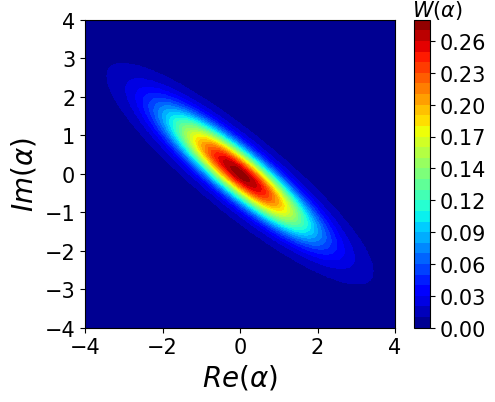

In [30]:
plt.figure(figsize=(5, 4))
p3=plt.contourf(xvec,yvec, W_STS, cmap=plt.cm.jet, levels=np.linspace(W_STS.min(),W_STS.max(), 30))
#plt.colorbar()
cb = plt.colorbar(p3, format=tkr.FormatStrFormatter('%.2f'))
cb.set_label(r'$W(\alpha)$', labelpad=-35, y=1.07, rotation=0, size=15)
cb.ax.tick_params(labelsize=15)
#plt.title(r'$|K|=10^{-2}\kappa$', fontsize=20)
plt.xlabel(r'$Re(\alpha)$', fontsize=20)
plt.ylabel(r'$Im(\alpha)$', fontsize=20)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.savefig("STS Wigner.jpeg", bbox_inches='tight')